<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/analysis/03_hypothesis_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import special

from os.path import join

import warnings
warnings.simplefilter('ignore')

final_data = pd.read_csv("final_dataset.csv", index_col=0)
final_data.head()

,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm),snowfall_sum (cm)
2005-01-31,46.650000,405.258065,126.2,7.006452,125.6,0.77
2005-02-28,72.679286,631.285714,108.5,5.996429,87.7,14.91
2005-03-31,92.837097,806.419355,66.8,7.090323,56.7,7.28
2005-04-30,92.331667,802.100000,36.1,11.813333,36.1,0.00
2005-05-31,87.719677,762.032258,12.3,16.148387,12.3,0.00


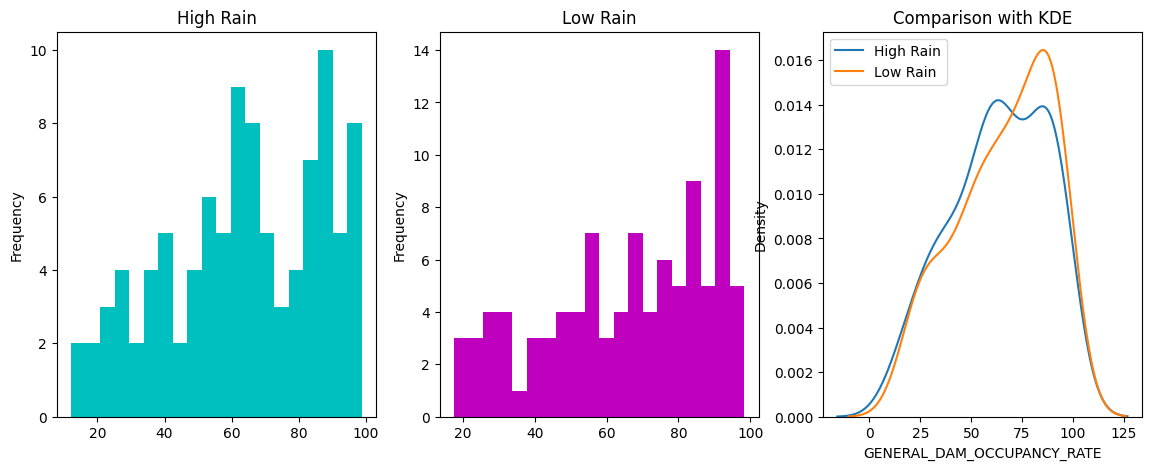

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14,5))

# High rain histogram
high_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(
    kind="hist", ax=ax[0], bins=20, color="c"
)
ax[0].set_title("High Rain")

# Low rain histogram
low_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(
    kind="hist", ax=ax[1], bins=20, color="m"
)
ax[1].set_title("Low Rain")

# KDE comparison
sns.kdeplot(high_rain["GENERAL_DAM_OCCUPANCY_RATE"], ax=ax[2], label="High Rain")
sns.kdeplot(low_rain["GENERAL_DAM_OCCUPANCY_RATE"], ax=ax[2], label="Low Rain")

ax[2].set_title("Comparison with KDE")
ax[2].legend()

plt.show()

H0 (Null Hypothesis): Rainfall has no effect on dam occupancy.

H1 (Alternative Hypothesis): Rainfall affects dam occupancy.

In [2]:
threshold = final_data["precipitation_sum (mm)"].median()

high_rain = final_data[final_data["precipitation_sum (mm)"] > threshold]
low_rain  = final_data[final_data["precipitation_sum (mm)"] <= threshold]

print(len(high_rain), len(low_rain))

high_dam = high_rain["GENERAL_DAM_OCCUPANCY_RATE"]
low_dam  = low_rain["GENERAL_DAM_OCCUPANCY_RATE"]



98 98


In [6]:
t_stat, p_value = stats.ttest_ind(high_dam, low_dam, equal_var=False)

print("p-value:", p_value)

p-value: 0.4146080609332651


In [7]:
if p_value < 0.05:
    print("Reject H0 → Rainfall affects dam occupancy")
else:
    print("Fail to reject H0 → No significant effect")

Fail to reject H0 → No significant effect


The results of the two-sample t-test show that there is no statistically significant difference in dam occupancy levels between high rainfall and low rainfall periods (p = 0.415). Therefore, we fail to reject the null hypothesis, suggesting that rainfall alone is not a sufficient factor in explaining reservoir levels.

This result is consistent with the exploratory data analysis, where no strong relationship was observed between rainfall and dam occupancy.